### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [1]:
from langchain.chat_models import init_chat_model
llm= init_chat_model(model="ollama:llama3.2:latest")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

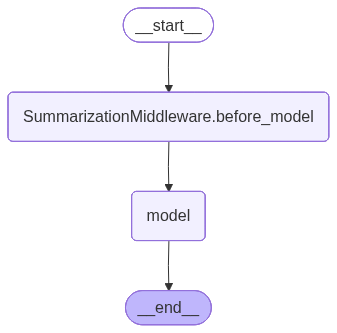

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage\

agent=create_agent(model="ollama:llama3.2:latest",checkpointer=InMemorySaver(),
                   middleware=[SummarizationMiddleware(
                       model="ollama:llama3.2:latest",
                       trigger=("messages",10),
                       keep=("messages", 4))])

agent


In [3]:
config={"configurable":{"thread_id":"test-1"}}


In [4]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {response['messages']}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='90b838b0-87a4-4c19-ba81-9a7517a671bc'), AIMessage(content='2 + 2 = 4.', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:10:39.9637411Z', 'done': True, 'done_reason': 'stop', 'total_duration': 505040700, 'load_duration': 118294100, 'prompt_eval_count': 32, 'prompt_eval_duration': 212226700, 'eval_count': 9, 'eval_duration': 163597500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd022-dedd-7401-88f7-f2368fe5eb8d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 9, 'total_tokens': 41})]}
Messages: [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='90b838b0-87a4-4c19-ba81-9a7517a671bc'), AIMessage(content='2 + 2 = 4.', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:10:39.9637411Z', 'done': True, 'don

## token Size

In [6]:
from langchain_core.tools import tool

@tool
def search_hotel(city:str)->str:
    """Search for hotels in a given city and return a list of hotels with their ratings and prices."""
    return f"Hotel in {city}: Hotel A -> 5 star $350/night spa pool gym, Hotel B-> 4 star $250/night pool, Hotel C-> 3 star $150/night basic amenities"



agent=create_agent(model="ollama:llama3.2:latest",checkpointer=InMemorySaver(),tools=[search_hotel],middleware=[SummarizationMiddleware(
                          model="ollama:llama3.2:latest",
                          trigger=("messages",10),
                          keep=("tokens", 550))])       

def count_tokens(messages):
    return sum(len(m.content.split()) for m in messages)//4

In [7]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~42 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='6b602dba-3b66-4c6f-9837-812782627d95'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:14:33.4054063Z', 'done': True, 'done_reason': 'stop', 'total_duration': 612527600, 'load_duration': 132944200, 'prompt_eval_count': 160, 'prompt_eval_duration': 280109500, 'eval_count': 18, 'eval_duration': 177782600, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd026-6e56-73a2-8183-5e26da936cb2-0', tool_calls=[{'name': 'search_hotel', 'args': {'city': 'Paris'}, 'id': '7ddeb32c-9ad2-46ac-88c5-3cbc3ba6eaba', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 160, 'output_tokens': 18, 'total_tokens': 178}), ToolMessage(content='Hotel in Paris: Hotel A -> 5 star $350/night spa pool gym, Hotel B-> 4 star $250/night pool, Hotel C-> 3 star $150/night basic amenities', name='search_h

### Fraction

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
import os 
from dotenv import load_dotenv
load_dotenv()
# ! only works if the model profile is provided is set if not it shows error so better use messages context as limit for messages and trigger and keep for tokens as well
os.environ["GEMINI_API_KEY"] = os.getenv("GOOGLE_API_KEY")

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    # model="ollama:llama3.2:latest",
    model="google_genai:gemini-2.5-flash-lite",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            # model="ollama:llama3.2:latest",
            model="google_genai:gemini-2.5-flash-lite",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

ValueError: Model profile information is required to use fractional token limits, and is unavailable for the specified model. Please use absolute token counts instead, or pass `

ChatModel(..., profile={"max_input_tokens": ...})`.

with a desired integer value of the model's maximum input tokens.

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str)->str:
    """Read an email by its ID and return the content."""
    return f"Email {email_id}: Subject: Meeting Reminder, From: john.doe@example.com"

def send_email_tool(to:str, subject:str, body:str)->str:
    """Send an email and return a confirmation message."""
    return f"Email sent to {to} with subject '{subject}' and body '{body}'"


In [28]:
agent=create_agent(
    model="ollama:llama3.2:latest",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)


In [29]:
config={"configurable":{"thread_id":"email-thread-3"}}
# result=agent.invoke({"messages":[HumanMessage(content="Read email with ID 12345")]},config)
# print(result)

In [30]:
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [31]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a53d723b-2a75-47db-84e0-138883074d78'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:31:38.4699968Z', 'done': True, 'done_reason': 'stop', 'total_duration': 791776900, 'load_duration': 119905700, 'prompt_eval_count': 220, 'prompt_eval_duration': 284728700, 'eval_count': 35, 'eval_duration': 350484500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd036-11cc-7693-82e8-999748b0cb97-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'c9987113-cb3a-4369-975b-1757a015f745', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'name': 'send_email_tool',

In [32]:
from langgraph.types import Command

if "__interrupt__"in result:
    print("Agent is waiting for human input...")
    result=agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),config=config
    )
    print(result)
    


Agent is waiting for human input...
{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a53d723b-2a75-47db-84e0-138883074d78'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:31:38.4699968Z', 'done': True, 'done_reason': 'stop', 'total_duration': 791776900, 'load_duration': 119905700, 'prompt_eval_count': 220, 'prompt_eval_duration': 284728700, 'eval_count': 35, 'eval_duration': 350484500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd036-11cc-7693-82e8-999748b0cb97-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'c9987113-cb3a-4369-975b-1757a015f745', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}), ToolMessage(content="Email sent to john@test.com w

In [33]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a53d723b-2a75-47db-84e0-138883074d78'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:31:38.4699968Z', 'done': True, 'done_reason': 'stop', 'total_duration': 791776900, 'load_duration': 119905700, 'prompt_eval_count': 220, 'prompt_eval_duration': 284728700, 'eval_count': 35, 'eval_duration': 350484500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd036-11cc-7693-82e8-999748b0cb97-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'c9987113-cb3a-4369-975b-1757a015f745', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}),
  ToolMessage(content="Email sent to john@test.com with subject 'Hello' and body 'Ho

### Reject

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str)->str:
    """Read an email by its ID and return the content."""
    return f"Email {email_id}: Subject: Meeting Reminder, From: john.doe@example.com"

def send_email_tool(to:str, subject:str, body:str)->str:
    """Send an email and return a confirmation message."""
    return f"Email sent to {to} with subject '{subject}' and body '{body}'"


In [35]:
agent=create_agent(
    model="ollama:llama3.2:latest",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)


In [36]:
config={"configurable":{"thread_id":"email-thread-4"}}
# result=agent.invoke({"messages":[HumanMessage(content="Read email with ID 12345")]},config)
# print(result)

In [37]:
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [38]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='378416f9-8da1-4007-b6e0-9727e2d90320'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:35:19.0078674Z', 'done': True, 'done_reason': 'stop', 'total_duration': 862401300, 'load_duration': 109166100, 'prompt_eval_count': 220, 'prompt_eval_duration': 364988600, 'eval_count': 35, 'eval_duration': 357016700, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd039-6f00-7260-9fc7-99d4951547f1-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': '81c3b960-357b-4a5a-ab36-56efdcfc9f1f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'name': 'send_email_tool',

In [39]:
from langgraph.types import Command

if "__interrupt__"in result:
    print("Agent is waiting for human input...")
    result=agent.invoke(
        Command(

            resume={
                "decisions":[
            # ! change the decision here to test different paths
                    {"type":"reject"}
                ]
            }
        ),config=config
    )
    print(result)
    


Agent is waiting for human input...
{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='378416f9-8da1-4007-b6e0-9727e2d90320'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:35:19.0078674Z', 'done': True, 'done_reason': 'stop', 'total_duration': 862401300, 'load_duration': 109166100, 'prompt_eval_count': 220, 'prompt_eval_duration': 364988600, 'eval_count': 35, 'eval_duration': 357016700, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd039-6f00-7260-9fc7-99d4951547f1-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': '81c3b960-357b-4a5a-ab36-56efdcfc9f1f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}), ToolMessage(content='User rejected the tool call f

In [40]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='378416f9-8da1-4007-b6e0-9727e2d90320'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:35:19.0078674Z', 'done': True, 'done_reason': 'stop', 'total_duration': 862401300, 'load_duration': 109166100, 'prompt_eval_count': 220, 'prompt_eval_duration': 364988600, 'eval_count': 35, 'eval_duration': 357016700, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd039-6f00-7260-9fc7-99d4951547f1-0', tool_calls=[{'name': 'send_email_tool', 'args': {'to': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': '81c3b960-357b-4a5a-ab36-56efdcfc9f1f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}),
  ToolMessage(content='User rejected the tool call for `send_email_tool` with id 81c

### edit

In [41]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str)->str:
    """Read an email by its ID and return the content."""
    return f"Email {email_id}: Subject: Meeting Reminder, From: john.doe@example.com"

def send_email_tool(to:str, subject:str, body:str)->str:
    """Send an email and return a confirmation message."""
    return f"Email sent to {to} with subject '{subject}' and body '{body}'"


In [48]:
agent=create_agent(
    model="ollama:llama3.2:latest",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)


In [49]:
config={"configurable":{"thread_id":"email-thread-6"}}
# result=agent.invoke({"messages":[HumanMessage(content="Read email with ID 12345")]},config)
# print(result)

In [50]:
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [51]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='934d82f1-26d9-4d23-b863-7483eb7a76ff'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:38:57.7561476Z', 'done': True, 'done_reason': 'stop', 'total_duration': 744382200, 'load_duration': 119108700, 'prompt_eval_count': 220, 'prompt_eval_duration': 237200900, 'eval_count': 35, 'eval_duration': 356194000, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd03c-c5f2-7db1-bcfe-aa10a35443e9-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'How are you?', 'to': 'john@test.com', 'subject': 'Hello'}, 'id': 'bf1ddd2c-4ed8-4222-a850-6c556ca0a945', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'name': 'send_email_tool',

In [52]:
from langgraph.types import Command

if "__interrupt__"in result:
    print("Agent is waiting for human input...")
    result=agent.invoke(
        Command(

            resume={
                "decisions":[
            # ! change the decision here to test different paths
                    {"type":"edit",
                     "edited_action":{
                         "name":"send_email_tool",
                         "args":{
                             "recipetent":"djai@langchain.com",
                             "subject":"Updated Subject",
                             "body":"Updated Body"
                         }
                     }}
                ]
            }
        ),config=config
    )
    print(result)
    


Agent is waiting for human input...
{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='934d82f1-26d9-4d23-b863-7483eb7a76ff'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:38:57.7561476Z', 'done': True, 'done_reason': 'stop', 'total_duration': 744382200, 'load_duration': 119108700, 'prompt_eval_count': 220, 'prompt_eval_duration': 237200900, 'eval_count': 35, 'eval_duration': 356194000, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd03c-c5f2-7db1-bcfe-aa10a35443e9-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipetent': 'djai@langchain.com', 'subject': 'Updated Subject', 'body': 'Updated Body'}, 'id': 'bf1ddd2c-4ed8-4222-a850-6c556ca0a945'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}), ToolMessage(content="Error 

In [53]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='934d82f1-26d9-4d23-b863-7483eb7a76ff'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-27T18:38:57.7561476Z', 'done': True, 'done_reason': 'stop', 'total_duration': 744382200, 'load_duration': 119108700, 'prompt_eval_count': 220, 'prompt_eval_duration': 237200900, 'eval_count': 35, 'eval_duration': 356194000, 'model_name': 'llama3.2:latest'}, id='lc_run--019dd03c-c5f2-7db1-bcfe-aa10a35443e9-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipetent': 'djai@langchain.com', 'subject': 'Updated Subject', 'body': 'Updated Body'}, 'id': 'bf1ddd2c-4ed8-4222-a850-6c556ca0a945'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 35, 'total_tokens': 255}),
  ToolMessage(content="Error invoking tool 'send_email_tool' 